In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [7]:
# data 
X = np.array([1,3,4,8,11,14,17,20]).reshape(-1,1)
y = np.array([10,15,22,35,50,65,75,85])

In [8]:
#function to plot any degree
def plt_polynomial(degree,color,label):
    # create a polynomial feature (column)
    poly = PolynomialFeatures(degree=degree,include_bias=False)
    X_poly = poly.fit_transform(X)
    
    # Train model 
    model = LinearRegression()
    model.fit(X_poly,y)
    # predict smooth curve for plotting
    X_smooth = np.linspace(0,25,200).reshape(-1,1)
    X_smooth_poly = poly.transform(X_smooth)
    y_smooth = model.predict(X_smooth_poly)
    
    plt.plot(X_smooth,y_smooth,color=color,linewidth=3,label=label)
    
    # print equation
    coeffs = model.coef_
    intercept = model.intercept_
    print(f"{label} Equation" )
    eq = f"y = {intercept:.2f}"
    for i ,c in enumerate(coeffs):
        eq += f"+ {c:.3f}*x^{i+1}"
    print(eq)
    return model , poly

LinearRegression degree 1 Equation
y = 4.60+ 4.105*x^1
Quadratic degree 1 Equation
y = 4.19+ 4.239*x^1+ -0.007*x^2
cubic degree 1 Equation
y = 7.81+ 2.137*x^1+ 0.242*x^2+ -0.008*x^3


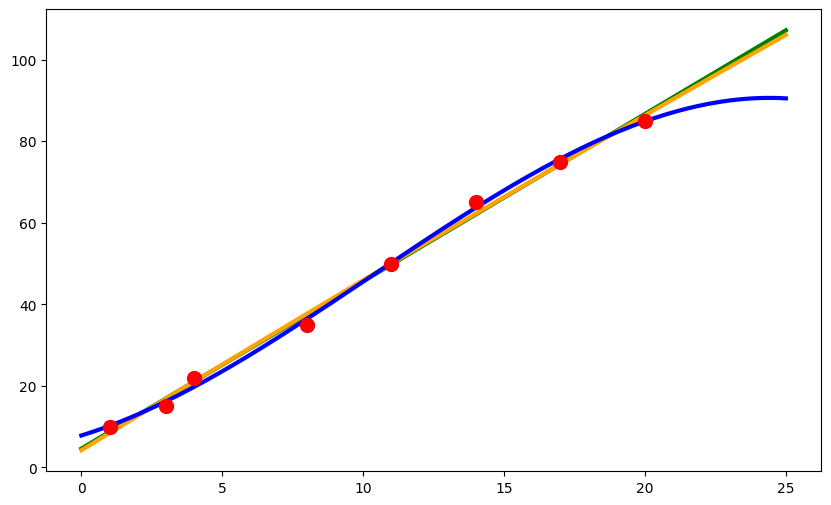

In [14]:
# polt print
plt.figure(figsize=(10,6))
plt.scatter(X,y,color='red', s = 100,label = "Actual Data " ,zorder=5)

# degree 1 
plt_polynomial(1,'green','LinearRegression degree 1')
#degree 2
plt_polynomial(2,'Orange','Quadratic degree 1')

#degree 3
plt_polynomial(3,'blue','cubic degree 1')

plt.show()